## Imports

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
from sklearn.metrics import f1_score
from sklearn.tree import DecisionTreeClassifier
import sklearn.tree as tree
from sklearn.model_selection import GroupKFold
import lime
import lime.lime_tabular
from sklearn.inspection import permutation_importance

## Load model and data

In [3]:
with open('models/decision-tree-trained.pkl', 'rb') as file:
    dt_model = pickle.load(file)

In [4]:
data = pd.read_csv("data/cleaned_static_features.csv",index_col=0)
with open("data/groups.pkl", 'rb') as file:
    groups = pickle.load(file)
disorders = ["Voice Disorders", "Neurological and Neurodegenerative Disorders", "Mood and Psychiatric Disorders","Respiratory Disorders"]
y_voice = data["Voice Disorders"].copy().to_numpy()
X_df = data.copy().drop(columns=["participant_id", "session_id","task_name","participant_id_int"]+disorders)
feature_names = X_df.columns
X = X_df.to_numpy()

In [5]:
feature_names = data.copy().drop(columns=["participant_id", "session_id","task_name","participant_id_int"]+disorders).columns

In [6]:
category_dict = {
    "spectral": [
        "spectralFlux_sma3_amean", "spectralFlux_sma3_stddevNorm", "spectralFluxV_sma3nz_amean", "spectralFluxV_sma3nz_stddevNorm",
        "spectralFluxUV_sma3nz_amean", "spectral_gravity", "spectral_std_dev", "spectral_skewness", "spectral_kurtosis",
        "alphaRatioV_sma3nz_amean", "alphaRatioV_sma3nz_stddevNorm", "alphaRatioUV_sma3nz_amean",
        "hammarbergIndexV_sma3nz_amean", "hammarbergIndexV_sma3nz_stddevNorm", "hammarbergIndexUV_sma3nz_amean", "hammarbergIndexUV_sma3nz_stddevNorm",
        "slopeV0-500_sma3nz_amean", "slopeV0-500_sma3nz_stddevNorm", "slopeV500-1500_sma3nz_amean", "slopeV500-1500_sma3nz_stddevNorm",
        "slopeUV0-500_sma3nz_amean", "slopeUV500-1500_sma3nz_amean", "spectral_slope", "spectral_tilt"
    ],
    "mfcc": [
        "mfcc1_sma3_amean", "mfcc1_sma3_stddevNorm","mfcc2_sma3_amean", "mfcc2_sma3_stddevNorm", 
        "mfcc3_sma3_amean", "mfcc3_sma3_stddevNorm", "mfcc4_sma3_amean", "mfcc4_sma3_stddevNorm",
        "mfcc1V_sma3nz_amean", "mfcc1V_sma3nz_stddevNorm","mfcc2V_sma3nz_amean", "mfcc2V_sma3nz_stddevNorm", 
        "mfcc3V_sma3nz_amean", "mfcc3V_sma3nz_stddevNorm", "mfcc4V_sma3nz_amean", "mfcc4V_sma3nz_stddevNorm" 
    ],
    "harmonic": [
        "logRelF0-H1-H2_sma3nz_amean", "logRelF0-H1-H2_sma3nz_stddevNorm", 
        "logRelF0-H1-A3_sma3nz_amean", "logRelF0-H1-A3_sma3nz_stddevNorm"
    ],
    "intensity": [
        "loudness_sma3_amean", "loudness_sma3_stddevNorm", "loudness_sma3_percentile20.0",
        "loudness_sma3_percentile50.0", "loudness_sma3_percentile80.0", "loudness_sma3_pctlrange0-2",
        "loudness_sma3_meanRisingSlope", "loudness_sma3_stddevRisingSlope", "loudness_sma3_meanFallingSlope", "loudness_sma3_stddevFallingSlope",
        "mean_intensity_db", "std_intensity_db", "range_ratio_intensity_db", "equivalentSoundLevel_dBp", "loudnessPeaksPerSec",
    ],
    "voice-quality-acoustic": [
        "HNRdBACF_sma3nz_amean", "HNRdBACF_sma3nz_stddevNorm", "mean_hnr_db", "std_hnr_db",
        "stoi", "pesq", "si_sdr"
    ],
    "pitch": [
        "F0semitoneFrom27.5Hz_sma3nz", "F0semitoneFrom27.5Hz_sma3nz_stddevNorm", "F0semitoneFrom27.5Hz_sma3nz_percentile20.0",
        "F0semitoneFrom27.5Hz_sma3nz_percentile50.0", "F0semitoneFrom27.5Hz_sma3nz_percentile80.0",
        "F0semitoneFrom27.5Hz_sma3nz_pctlrange0-2", "F0semitoneFrom27.5Hz_sma3nz_meanRisingSlope",
        "F0semitoneFrom27.5Hz_sma3nz_stddevRisingSlope", "F0semitoneFrom27.5Hz_sma3nz_meanFallingSlope", "F0semitoneFrom27.5Hz_sma3nz_amean",
        "F0semitoneFrom27.5Hz_sma3nz_stddevFallingSlope", "mean_f0_hertz", "std_f0_hertz"
    ],
    "formants": [
        "mean_f1_loc", "std_f1_loc", "mean_b1_loc", "std_b1_loc", "mean_f2_loc", "std_f2_loc", "mean_b2_loc", "std_b2_loc",
        "F0semitoneFrom27.5Hz_sma3nz_amean", "F1frequency_sma3nz_amean", "F1frequency_sma3nz_stddevNorm", "F1bandwidth_sma3nz_amean", 
        "F1bandwidth_sma3nz_stddevNorm", "F1amplitudeLogRelF0_sma3nz_amean", "F1amplitudeLogRelF0_sma3nz_stddevNorm",
        "F2frequency_sma3nz_amean", "F2frequency_sma3nz_stddevNorm", "F2bandwidth_sma3nz_amean", "F2bandwidth_sma3nz_stddevNorm",
        "F2amplitudeLogRelF0_sma3nz_amean", "F2amplitudeLogRelF0_sma3nz_stddevNorm", "F3frequency_sma3nz_amean",
        "F3frequency_sma3nz_stddevNorm", "F3bandwidth_sma3nz_amean", "F3bandwidth_sma3nz_stddevNorm", "F3amplitudeLogRelF0_sma3nz_amean",
        "F3amplitudeLogRelF0_sma3nz_stddevNorm"
    ],
    "voice-quality-phonetic": [
        "jitterLocal_sma3nz_amean", "local_jitter", "localabsolute_jitter", "rap_jitter", "ppq5_jitter", "ddp_jitter",
        "shimmerLocaldB_sma3nz", "local_shimmer", "localDB_shimmer", "apq3_shimmer", "apq5_shimmer", "apq11_shimmer", "dda_shimmer",
        "cepstral_peak_prominence_mean", "cepstral_peak_prominence_std",
        "jitterLocal_sma3nz_stddevNorm", "shimmerLocaldB_sma3nz_amean", "shimmerLocaldB_sma3nz_stddevNorm"
    ],
    "temporal-rhythmic": [
        "duration", "speaking_rate", "articulation_rate", "phonation_ratio", "pause_rate", "mean_pause_duration",
        "VoicedSegmentsPerSec", "MeanVoicedSegmentLengthSec", "StddevVoicedSegmentLengthSec",
        "MeanUnvoicedSegmentLength", "StddevUnvoicedSegmentLength"
    ]
}

feature_cat_dict = {}
for feat in feature_names:
    for feat_cat in category_dict:
        if feat in category_dict[feat_cat]:
            feature_cat_dict[feat] = feat_cat

acoustic_feats = [category_dict[feat_cat] for feat_cat in category_dict if feat_cat in ["spectral", "mfcc", "harmonic", "voice-quality-acoustic", "intensity"]]
phonetic_feats = [category_dict[feat_cat] for feat_cat in category_dict if feat_cat not in ["spectral", "mfcc", "harmonic", "voice-quality", "intensity"]]

## Train and test

In [7]:
def train_test_split_groups(y, groups, total_n_groups:int, split_size:float=0.15):
    n_test_groups = int(total_n_groups*0.15)
    group_ones = groups[np.where(y==1)[0]]
    group_zeros = groups[np.where(y==0)[0]]
    test_groups_one = np.random.choice(group_ones, int(n_test_groups/2), replace=False)
    test_groups_zero = np.random.choice(group_zeros, int(n_test_groups/2), replace=False)
    test_groups = np.concatenate((test_groups_one, test_groups_zero))
    train_groups = np.array([g for g in groups if g not in test_groups])
    train_inds = np.array([i for i in range(len(y)) if groups[i] in train_groups])
    test_inds = np.array([i for i in range(len(y)) if groups[i] in test_groups])
    return train_inds, test_inds

In [8]:
train_idx, test_idx = train_test_split_groups(y_voice, groups, total_n_groups=440)
X_train, y_train = X[train_idx], y_voice[train_idx]
X_test, y_test = X[test_idx], y_voice[test_idx]

gkf = GroupKFold(n_splits=7,shuffle=False)
fold_results = []

for fold_idx, (tr_idx, val_idx) in enumerate(gkf.split(X_train, y_train, groups=groups[train_idx])):
    # Train/test split at group level
    X_tr, y_tr = X_train[tr_idx], y_train[tr_idx]
    X_val, y_val = X_train[val_idx], y_train[val_idx]

    # Fit on training groups
    dt_model.fit(X_tr, y_tr)

    # Evaluate on training groups (report group-level aggregated performance)
    y_tr_pred = dt_model.predict(X_tr)
    train_f1 = f1_score(y_tr, y_tr_pred, average='weighted')

    # Evaluate on held-out group (validation)
    y_val_pred = dt_model.predict(X_val)
    val_f1 = f1_score(y_val, y_val_pred, average='weighted')

    fold_results.append({
        'fold': fold_idx,
        'train_idx_count': len(tr_idx),
        'val_idx_count': len(val_idx),
        'train_f1': train_f1,
        'val_f1': val_f1,
        'val_groups': np.unique(groups[val_idx]).tolist()
    })

# Convert to DataFrame for easier plotting/analysis
decision_tree_gkf_fold_results = pd.DataFrame(fold_results)
print('Per-fold GKF results (first 10 rows):')
decision_tree_gkf_fold_results.head(10)

Per-fold GKF results (first 10 rows):


,fold,train_idx_count,val_idx_count,train_f1,val_f1,val_groups
0,0,13609,2277,0.652970,0.587725,"[4, 5, 11, 12, 13, 15, 16, 25, 37, 38, 39, 40,..."
1,1,13611,2275,0.667701,0.569034,"[1, 10, 11, 14, 15, 18, 29, 30, 38, 39, 44, 48..."
2,2,13618,2268,0.672975,0.536849,"[1, 2, 19, 20, 22, 23, 30, 31, 32, 33, 34, 35,..."
3,3,13621,2265,0.654935,0.649173,"[1, 27, 28, 40, 41, 42, 45, 46, 47, 48, 56, 57..."
4,4,13609,2277,0.646189,0.647412,"[1, 8, 9, 10, 13, 14, 18, 19, 28, 45, 46, 49, ..."
5,5,13638,2248,0.644514,0.667631,"[0, 2, 3, 4, 6, 7, 8, 21, 22, 23, 24, 25, 28, ..."
6,6,13610,2276,0.660118,0.608169,"[1, 5, 6, 13, 16, 17, 20, 21, 26, 27, 35, 36, ..."


In [9]:
# final eval
y_test_preds = dt_model.predict(X_test)
test_f1 = f1_score(y_test, y_test_preds, average="weighted")
print(f"Test F1 (weighted): {np.round(test_f1,2)}")

Test F1 (weighted): 0.69


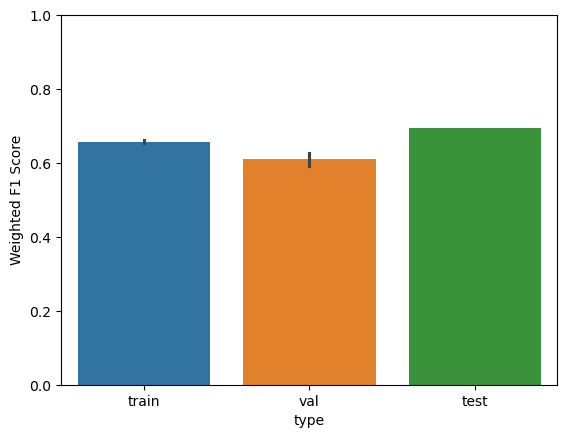

In [10]:
train_f1 = decision_tree_gkf_fold_results["train_f1"].mean()
val_f1 = decision_tree_gkf_fold_results["val_f1"].mean()

results_dict = {"f1":[], "type":[]}
for idx,row in decision_tree_gkf_fold_results.iterrows():
    results_dict["f1"].append(row.train_f1)
    results_dict["type"].append("train")
    results_dict["f1"].append(row.val_f1)
    results_dict["type"].append("val")
results_dict["f1"].append(test_f1)
results_dict["type"].append("test")

results_df = pd.DataFrame.from_dict(results_dict)

plt.figure()
sns.barplot(data=results_df, x="type", y="f1", palette="tab10", hue="type", errorbar="se")
plt.ylabel("Weighted F1 Score")
plt.ylim([0, 1.0])
plt.show()

## Explainability

#### Tree structure

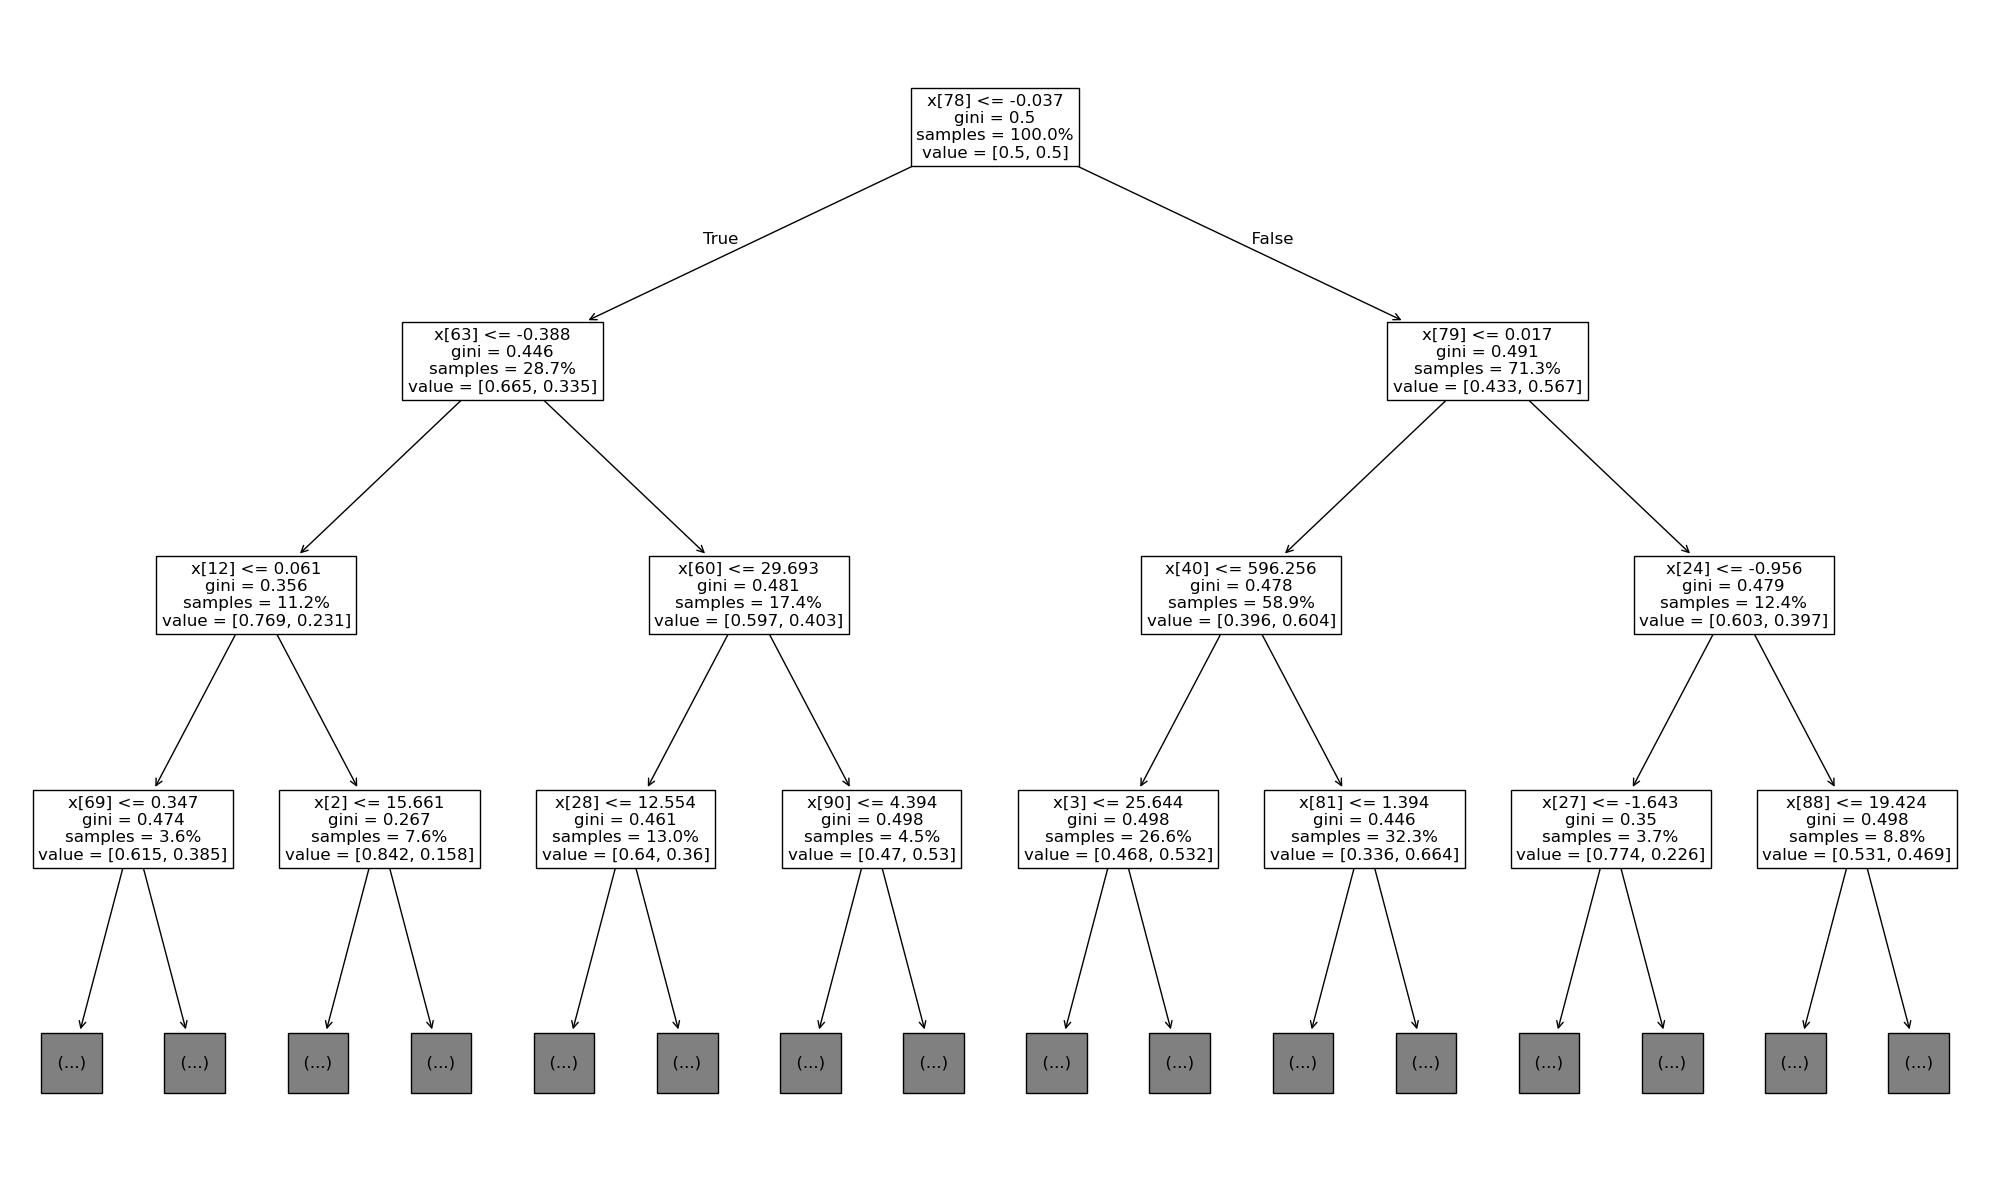

In [11]:
fig,ax = plt.subplots(1,1,figsize=(20,12))
tree.plot_tree(dt_model, proportion=True, max_depth=3, ax=ax,fontsize=12)
plt.tight_layout()
plt.show()

#### Gini impurity
- The impurity-based feature importances. The higher, the more important the feature. The importance of a feature is computed as the (normalized) total reduction of the criterion brought by that feature.

In [12]:
mdi_importances = pd.DataFrame.from_dict({
    "mdi":dt_model.feature_importances_, "feature":feature_names
}).sort_values(by="mdi",ascending=False)
mdi_importances

,mdi,feature
78,0.285547,slopeUV0-500_sma3nz_amean
79,0.108979,slopeUV500-1500_sma3nz_amean
40,0.061580,F1frequency_sma3nz_amean
2,0.051314,F0semitoneFrom27.5Hz_sma3nz_percentile20.0
63,0.050325,slopeV0-500_sma3nz_stddevNorm
...,...,...
36,0.000000,logRelF0-H1-H2_sma3nz_amean
35,0.000000,HNRdBACF_sma3nz_stddevNorm
34,0.000000,HNRdBACF_sma3nz_amean
33,0.000000,shimmerLocaldB_sma3nz_stddevNorm


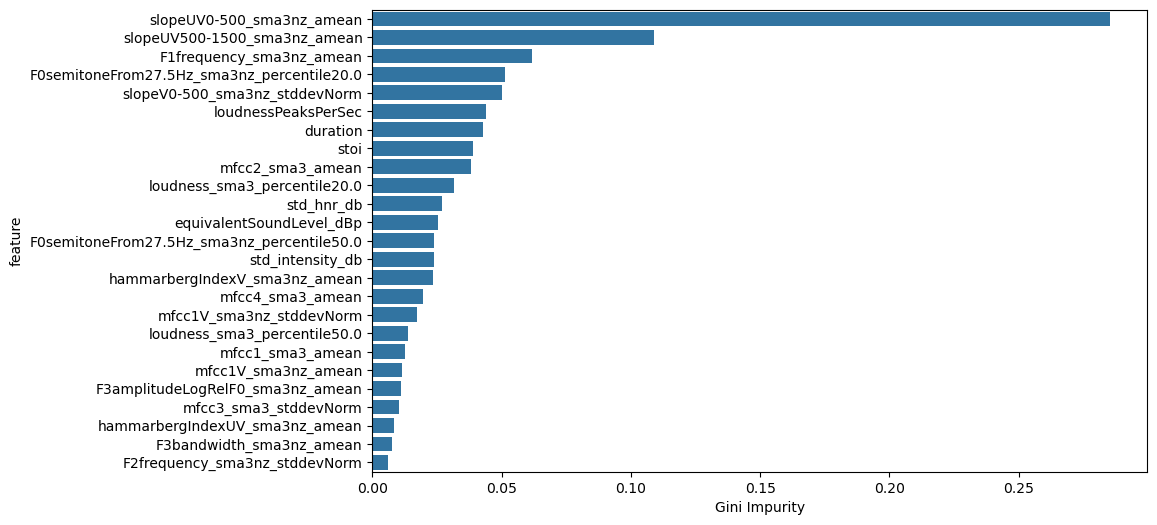

In [16]:
fig,ax = plt.subplots(1,1,figsize=(10,6))
sns.barplot(data=mdi_importances[:25],x="mdi",y="feature",orient="h")
ax.set_xlabel("Gini Impurity")
plt.show()

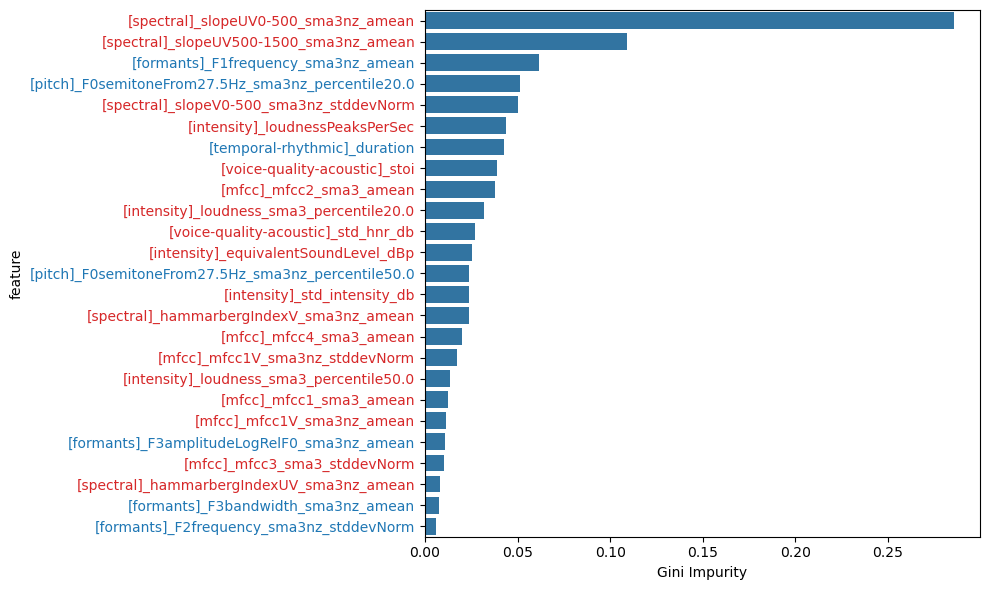

In [26]:
labels = [f"[{feature_cat_dict.get(lab)}]_"+lab for lab in mdi_importances[:25].feature]
feature_cmap = {
    "spectral":"tab:red",
    "mfcc":"tab:red",
    "harmonic":"tab:red",
    "intensity":"tab:red",
    "voice-quality-acoustic":"tab:red",
    "pitch":"tab:blue",
    "formants":"tab:blue",
    "voice-quality-phonetic":"tab:blue",
    "temporal-rhythmic":"tab:blue"
}
colors =  [feature_cmap.get(feature_cat_dict.get(lab)) for lab in mdi_importances[:25].feature]

fig,ax = plt.subplots(1,1,figsize=(10,6))
sns.barplot(data=mdi_importances[:25],x="mdi",y="feature",orient="h",ax=ax)
ax.set_xlabel("Gini Impurity")
yticklabels = ax.get_yticklabels()
for lab,c in zip(yticklabels,colors):
    lab.set_color(c)
ax.set_yticks(np.arange(len(labels)), labels)
plt.tight_layout()
plt.show()

#### Permutation feature importance
- "Permutation feature importance is a model inspection technique that measures the contribution of each feature to a fitted model’s statistical performance on a given tabular dataset. This technique is particularly useful for non-linear or opaque estimators, and involves randomly shuffling the values of a single feature and observing the resulting degradation of the model’s score [1]. By breaking the relationship between the feature and the target, we determine how much the model relies on such particular feature."

In [105]:
result = permutation_importance(
    dt_model, X_test, y_test, n_repeats=10, random_state=42, n_jobs=2
)

sorted_importances_idx = result.importances_mean.argsort()
importances = pd.DataFrame(
    result.importances[sorted_importances_idx].T,
    columns=feature_names[sorted_importances_idx],
)
importances

,mfcc1_sma3_stddevNorm,mfcc4_sma3_stddevNorm,F0semitoneFrom27.5Hz_sma3nz_amean,slopeV0-500_sma3nz_stddevNorm,slopeV0-500_sma3nz_amean,hammarbergIndexV_sma3nz_stddevNorm,hammarbergIndexV_sma3nz_amean,alphaRatioV_sma3nz_amean,F3amplitudeLogRelF0_sma3nz_stddevNorm,F3amplitudeLogRelF0_sma3nz_amean,...,equivalentSoundLevel_dBp,F2bandwidth_sma3nz_stddevNorm,std_intensity_db,duration,mfcc4_sma3_amean,mfcc2_sma3_amean,F0semitoneFrom27.5Hz_sma3nz_percentile80.0,F1frequency_sma3nz_amean,slopeUV500-1500_sma3nz_amean,slopeUV0-500_sma3nz_amean
0,-0.001843,-0.000307,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.003378,0.005528,0.007371,0.008907,0.012592,0.023956,0.024263,0.035627,0.029484,0.103501
1,-0.002150,-0.003071,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.002150,0.003071,0.004914,0.008600,0.012592,0.019656,0.026106,0.031941,0.041462,0.092138
2,-0.001843,0.000614,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.003071,0.006757,0.005528,0.008292,0.011364,0.018735,0.029484,0.035627,0.039926,0.108415
3,-0.001536,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.003686,0.000921,0.004300,0.014128,0.011057,0.021806,0.035319,0.027334,0.035319,0.090909
4,-0.002457,-0.000614,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.005528,0.006757,0.005221,0.003686,0.012285,0.019656,0.030405,0.033784,0.039312,0.088145
5,-0.001843,-0.003071,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.003686,0.006757,0.006757,0.007371,0.012285,0.016892,0.036241,0.030098,0.030713,0.089681
6,-0.000921,-0.002764,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.003993,0.006143,0.007678,0.004607,0.011978,0.022113,0.037162,0.031020,0.039619,0.096744
7,-0.002457,0.000307,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.006143,0.006143,0.003378,0.011978,0.013206,0.020577,0.030098,0.029177,0.036241,0.090295
8,-0.000921,-0.001536,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.004607,0.003378,0.008292,0.010135,0.012592,0.019349,0.039312,0.037776,0.031941,0.100737
9,-0.001536,-0.001843,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.001536,0.003993,0.006757,0.013206,0.011978,0.023342,0.035012,0.034705,0.037776,0.095823


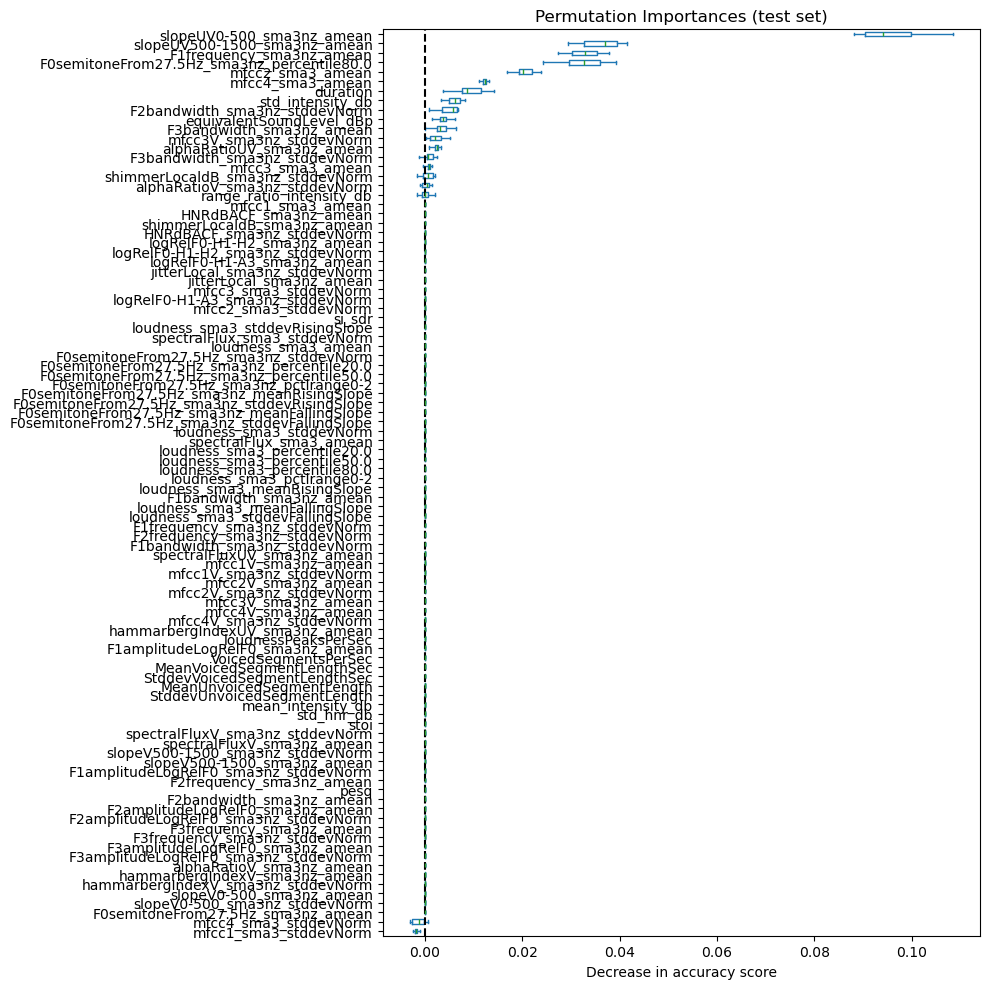

In [118]:
ax = importances.plot.box(vert=False, whis=10, figsize=(10,10))
ax.set_title("Permutation Importances (test set)")
ax.axvline(x=0, color="k", linestyle="--")
ax.set_xlabel("Decrease in accuracy score")
ax.figure.tight_layout()
plt.show()

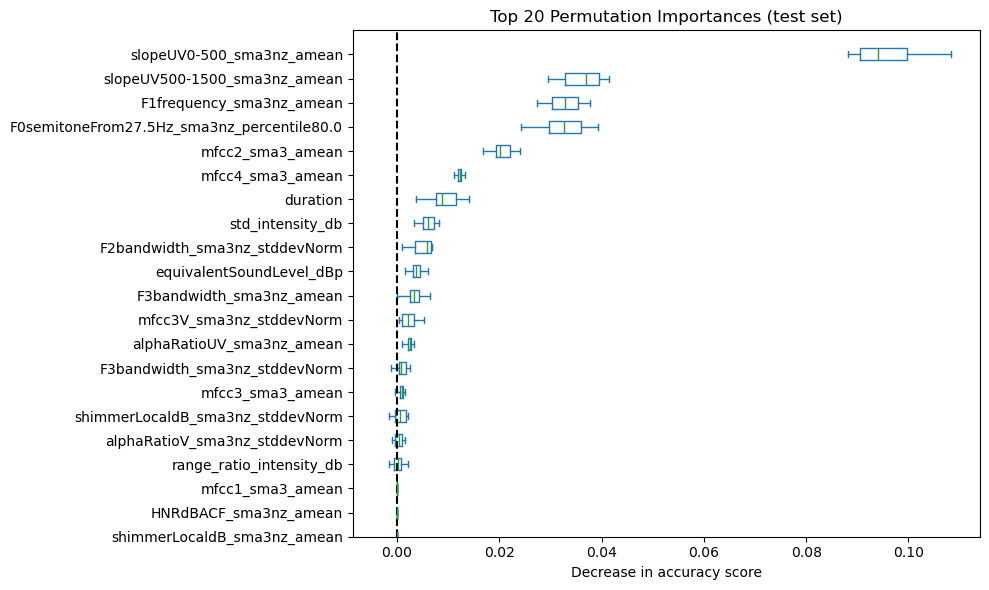

In [115]:
ax = importances.plot.box(vert=False, whis=10, figsize=(10,6))
ax.set_title("Top 20 Permutation Importances (test set)")
ax.axvline(x=0, color="k", linestyle="--")
ax.set_xlabel("Decrease in accuracy score")
ax.set_ylim([len(feature_names)-20,len(feature_names)+1])
ax.figure.tight_layout()

#### Check permutation feature importance for training set too

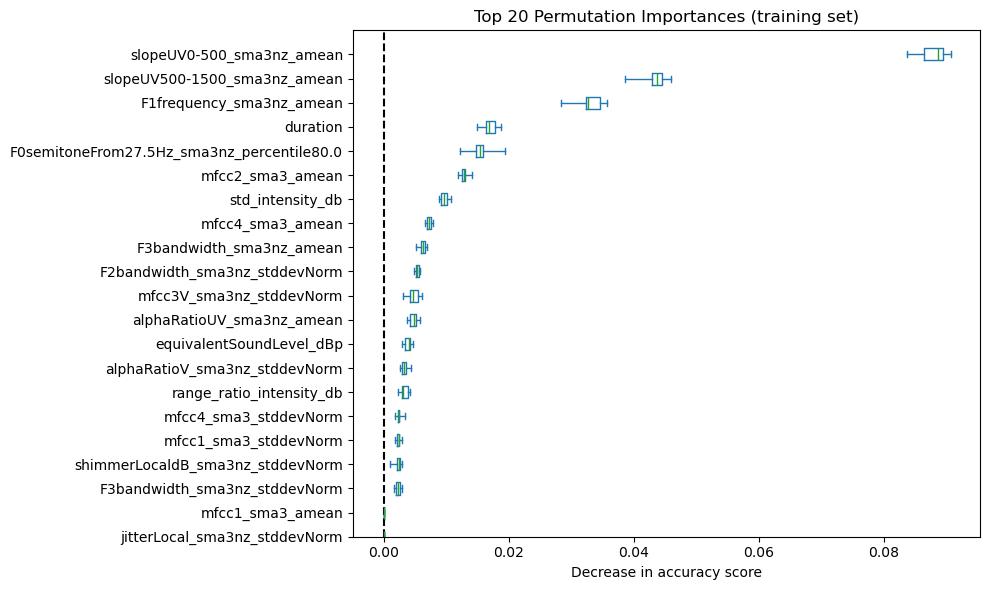

In [120]:
result = permutation_importance(
    dt_model, X_train, y_train, n_repeats=10, random_state=42, n_jobs=2
)

sorted_importances_idx = result.importances_mean.argsort()
importances = pd.DataFrame(
    result.importances[sorted_importances_idx].T,
    columns=feature_names[sorted_importances_idx],
)

ax = importances.plot.box(vert=False, whis=10, figsize=(10,6))
ax.set_title("Top 20 Permutation Importances (training set)")
ax.axvline(x=0, color="k", linestyle="--")
ax.set_xlabel("Decrease in accuracy score")
ax.set_ylim([len(feature_names)-20,len(feature_names)+1])
ax.figure.tight_layout()